# 1. Import Libraries

This section imports the Python libraries required for data manipulation, visualization, and machine learning throughout the project.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# 2. Load the Olist Datasets

The Olist dataset consists of multiple related tables. For this project, we use the four core datasets required to build a customer churn prediction model:

- Customers
- Orders
- Order Items
- Payments

In [4]:
customer_features = pd.read_csv(r"C:\Users\LENOVO\Documents\Data Science Projects\churn prediction\Data\Processed\customer_features.csv")
customer_features.head()


,customer_unique_id,total_orders,total_spent,avg_order_value,avg_items,total_freight,avg_installments,first_purchase,last_purchase,customer_state,customer_city,recency,frequency,monetary,tenure,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,12.00,8.0,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,cajamar,21,1,141.90,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,8.29,1.0,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,osasco,24,1,27.19,0,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,17.22,8.0,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,sao jose,446,1,86.22,0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,17.63,4.0,2017-10-12 20:29:41,2017-10-12 20:29:41,PA,belem,230,1,43.62,0,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,16.89,6.0,2017-11-14 19:45:42,2017-11-14 19:45:42,SP,sorocaba,197,1,196.89,0,1


In [5]:
customer_features['first_purchase'] = pd.to_datetime(customer_features['first_purchase'])
customer_features['last_purchase'] = pd.to_datetime(customer_features['last_purchase'])

# 3. Exploratory Data Analysis (EDA)

The customer-level dataset is analyzed to understand purchasing behavior and identify patterns associated with customer churn.

The objectives of the EDA are to:

- Understand the distribution of the target variable.
- Compare customer behavior between active and churned customers.
- Analyze the impact of RFM (Recency, Frequency, Monetary) features.
- Explore customer tenure and spending patterns.
- Identify relationships among numerical features.
- Generate business insights that can support customer retention strategies.

## 3.1 Distribution of Customer Churn

The first step is to examine the distribution of the target variable.

Understanding the proportion of active and churned customers helps identify class imbalance, which influences model selection and evaluation.

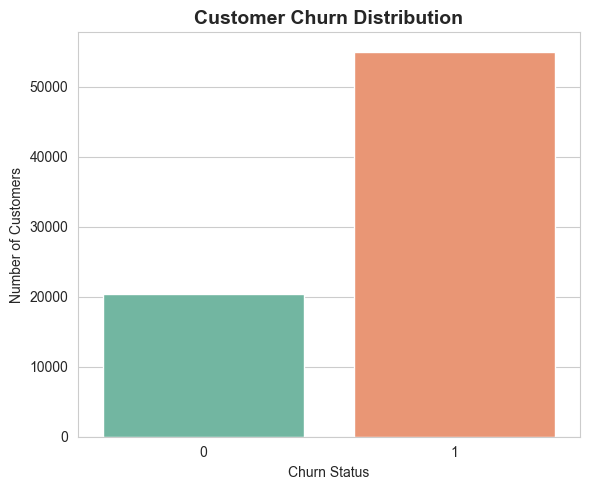

In [11]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,5))

sns.countplot(
    data=customer_features,
    x='churn',
    hue='churn',
    palette='Set2',
    legend=False
)

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## 3.2 RFM Feature Analysis

Recency, Frequency, and Monetary (RFM) features are among the strongest indicators of customer purchasing behavior.

Box plots are used to compare the distributions of these features for active and churned customers.

This analysis helps determine whether customer spending, purchase frequency, and purchase recency differ significantly between the two groups.

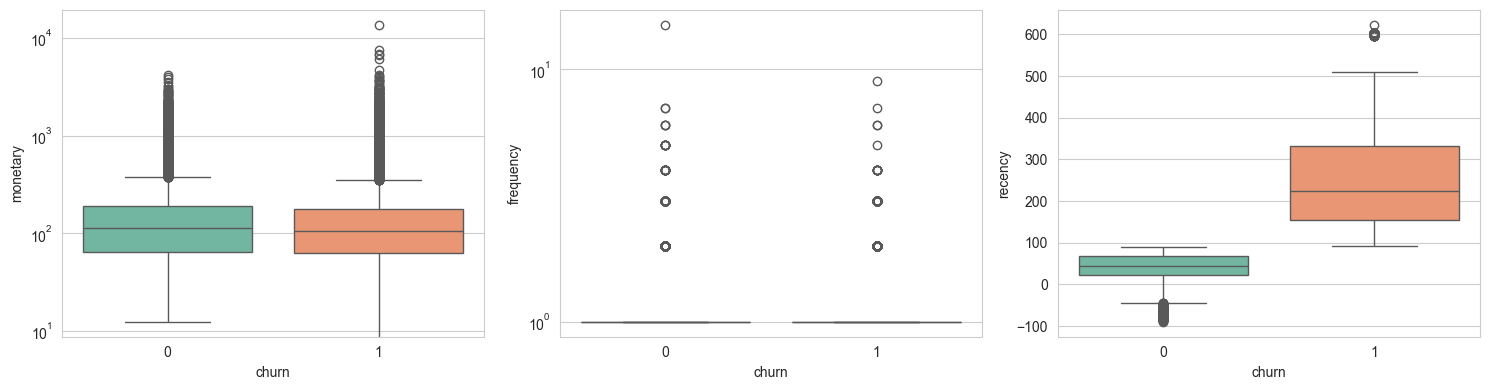

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(
    data=customer_features,
    x='churn',
    y='monetary',
    hue='churn',
    palette='Set2',
    legend=False,
    ax=axes[0]
)

sns.boxplot(
    data=customer_features,
    x='churn',
    y='frequency',
    hue='churn',
    palette='Set2',
    legend=False,
    ax=axes[1]
)

sns.boxplot(
    data=customer_features,
    x='churn',
    y='recency',
    hue='churn',
    palette='Set2',
    legend=False,
    ax=axes[2]
)
axes[0].set_yscale('log')  
axes[1].set_yscale('log')   
plt.tight_layout()
plt.show()

### Observation

The RFM analysis highlights noticeable differences between active and churned customers.

- Customers with higher **recency** values are more likely to have churned, indicating longer periods of inactivity.
- Customers with higher **frequency** generally exhibit stronger engagement and lower churn risk.
- Customers with higher **monetary value** tend to contribute more revenue and may demonstrate different retention patterns.

These findings suggest that purchasing behavior plays a significant role in predicting customer churn.

## 3.3 Customer Tenure Analysis

Customer tenure represents the duration of the relationship between a customer and the business.

Analyzing tenure across churn groups helps determine whether long-term customers are less likely to churn than newly acquired customers.

<Axes: xlabel='churn', ylabel='tenure'>

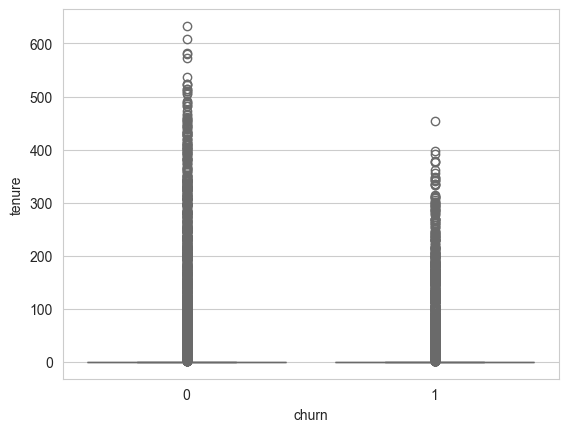

In [13]:
sns.boxplot(
    data=customer_features,
    x='churn',
    y='tenure',
    hue='churn',
    palette='Set3',
    legend=False
)


### Observation

The distribution of customer tenure provides insight into the relationship between customer loyalty and churn. Differences in tenure between active and churned customers can help determine whether long-term engagement reduces the likelihood of customer attrition.

## 3.4 Distribution of Customer Features

Understanding the distribution of key numerical features helps identify customer purchasing patterns, skewness, and potential outliers.

The following variables are examined:

- Total Spending
- Total Orders
- Average Order Value
- Customer Tenure

These distributions provide valuable insights into customer behavior and help determine whether feature transformations may be required before model training.

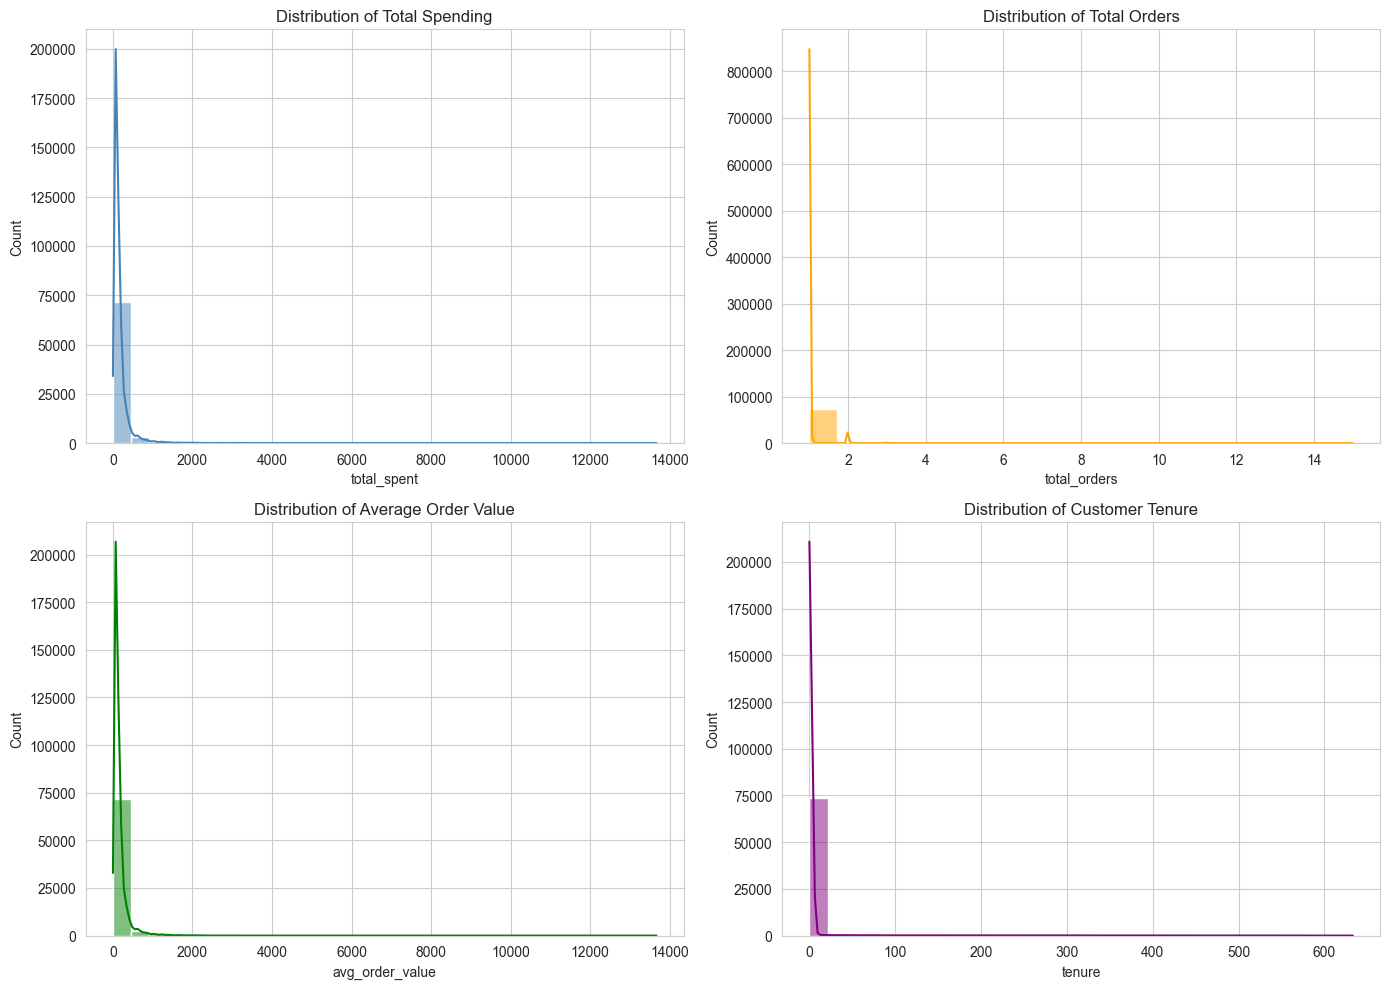

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(customer_features['total_spent'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Total Spending')

sns.histplot(customer_features['total_orders'], bins=20, kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribution of Total Orders')

sns.histplot(customer_features['avg_order_value'], bins=30, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Distribution of Average Order Value')

sns.histplot(customer_features['tenure'], bins=30, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Distribution of Customer Tenure')

plt.tight_layout()
plt.show()

### Observation

The distributions reveal the purchasing behavior of customers across multiple dimensions.

- Spending and average order value may exhibit right-skewed distributions, indicating that a small number of customers contribute significantly more revenue than the average customer.
- Total orders help identify repeat buyers versus one-time purchasers.
- Customer tenure highlights differences between newly acquired and long-term customers.

These observations provide useful context for understanding customer behavior and may guide feature scaling or transformation during model development.

## 3.5 Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical features.

Understanding feature correlations helps identify potential redundancy, dependencies, and the variables that are most strongly associated with customer churn.

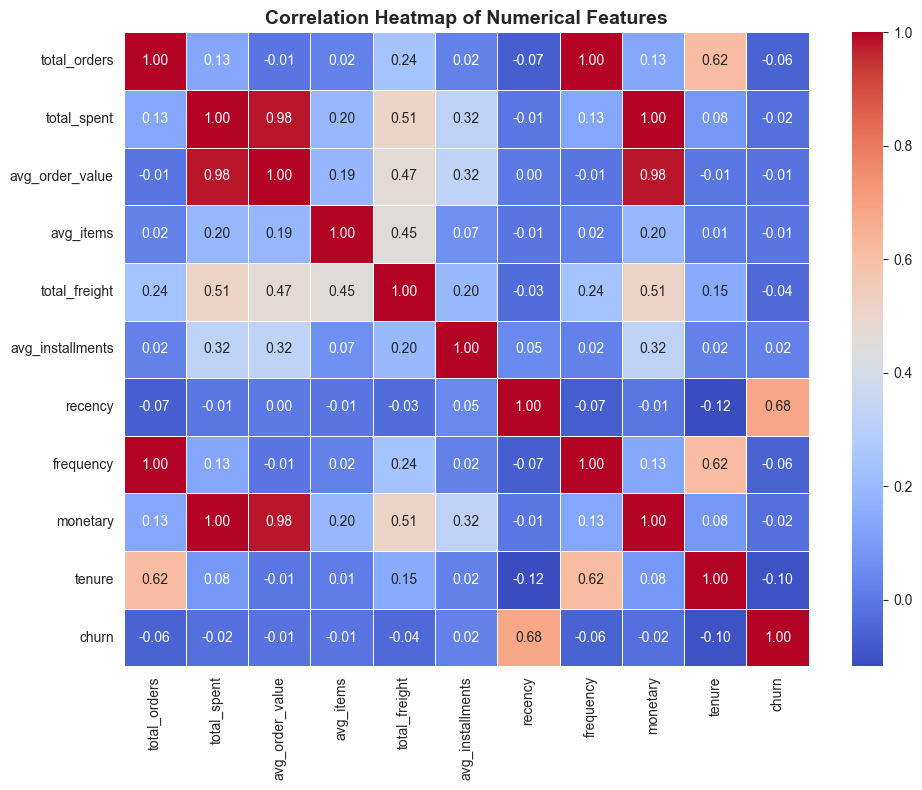

In [15]:
plt.figure(figsize=(10,8))

numerical_features = customer_features.select_dtypes(include=['number'])

correlation_matrix = numerical_features.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap illustrates the relationships among the engineered numerical features.

Strong correlations between related variables (such as monetary value and total spending) are expected, while weaker correlations indicate that features capture different aspects of customer behavior.

The heatmap also provides an initial indication of which variables may have stronger associations with the churn target.

## 3.6 Customer Churn by State

Customer churn is analyzed across different states to identify regional differences in customer retention.

Understanding geographical variations in churn can help businesses develop location-specific marketing and customer retention strategies.

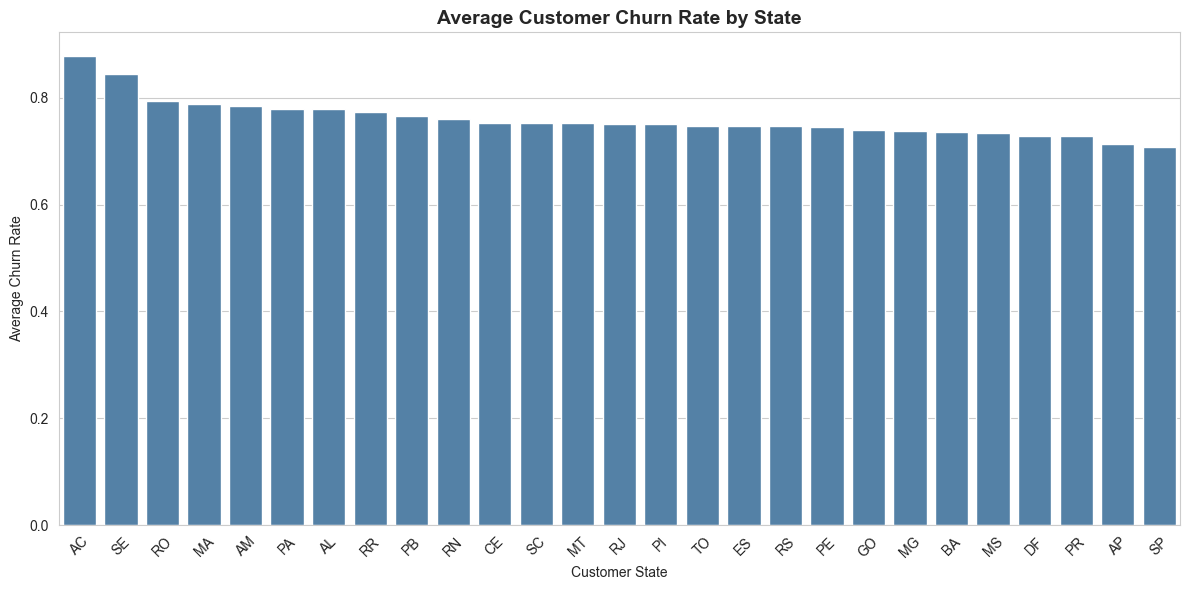

In [16]:
state_churn = (
    customer_features
    .groupby('customer_state')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_churn.index,
    y=state_churn.values,
    color='steelblue'
)

plt.title('Average Customer Churn Rate by State', fontsize=14, fontweight='bold')
plt.xlabel('Customer State')
plt.ylabel('Average Churn Rate')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The churn rate varies across different states, indicating that customer retention may differ geographically. These insights can support targeted marketing campaigns and region-specific customer engagement strategies.

## 3.7 Customer Distribution by State

The distribution of customers across states is analyzed to identify the regions with the highest customer concentration.

This analysis provides business insight into the company's major markets and customer base.

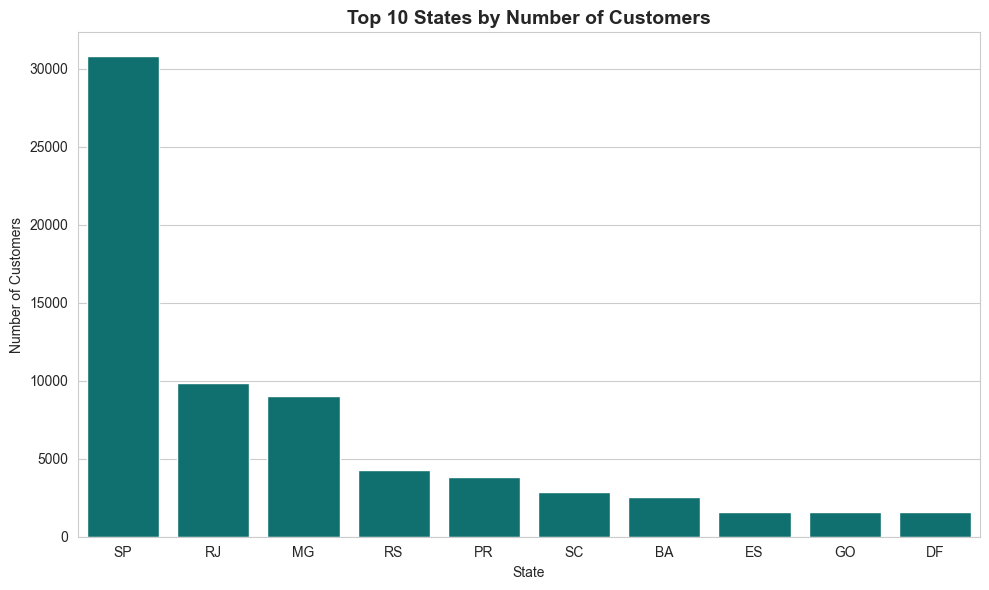

In [17]:
top_states = customer_features['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values,
    color='teal'
)

plt.title('Top 10 States by Number of Customers', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation

The visualization identifies the states with the highest customer populations. Businesses can use this information to prioritize customer acquisition and retention efforts in their largest markets.

## 3.8 Churn Rate by Purchase Frequency

This analysis examines how customer churn varies with the number of completed purchases.

Repeat customers are generally expected to have lower churn rates than one-time buyers.

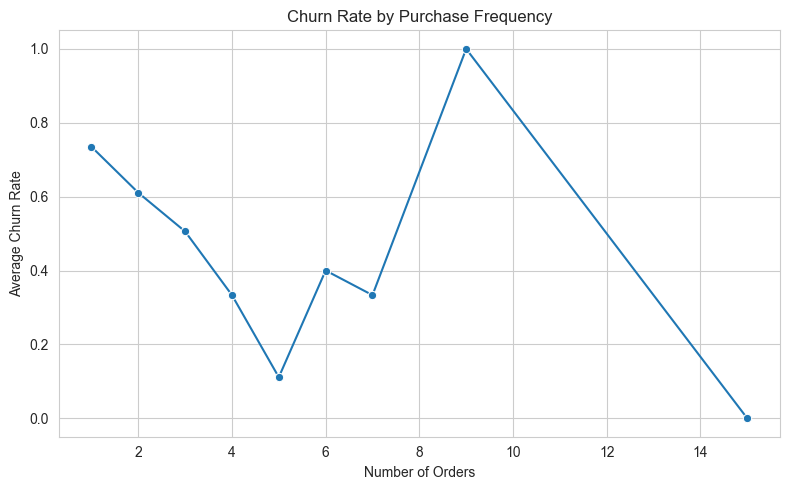

In [18]:
frequency_churn = (
    customer_features
    .groupby('frequency')['churn']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=frequency_churn,
    x='frequency',
    y='churn',
    marker='o'
)

plt.title('Churn Rate by Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Average Churn Rate')

plt.tight_layout()
plt.show()

### Observation

The churn rate decreases as the number of completed purchases increases. Customers who make only one or two purchases are more likely to churn, whereas repeat customers exhibit significantly lower churn rates.

This trend suggests that encouraging repeat purchases through loyalty programs, personalized recommendations, or targeted promotions could improve customer retention and reduce churn.

## 3.9 Top Customer Cities

The distribution of customers across cities is analyzed to identify the company's largest markets.

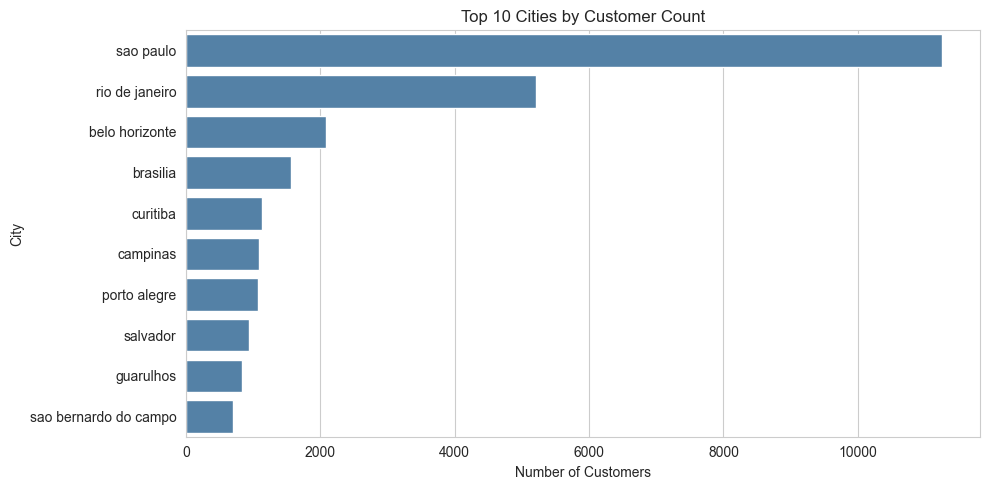

In [19]:
top_cities = customer_features['customer_city'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    color='steelblue'
)

plt.title('Top 10 Cities by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('City')

plt.tight_layout()
plt.show()


### Observation

The customer base is concentrated in a few major cities, indicating that these locations represent the company's primary markets. This concentration presents opportunities for targeted marketing campaigns, localized promotions, and customer retention initiatives in high-value regions.

Understanding the geographic distribution of customers can also support strategic decisions related to inventory management, logistics, and regional business expansion.

## 3.10 Pairwise Relationship of Key Features

A pair plot is used to visualize the relationships among the key numerical features while distinguishing customers by churn status.

Since the complete dataset contains a large number of customer records, plotting every observation would lead to excessive overplotting and reduced readability. Therefore, a random sample of **2,000 customers** is used to provide a clearer visual representation while preserving the overall data distribution.

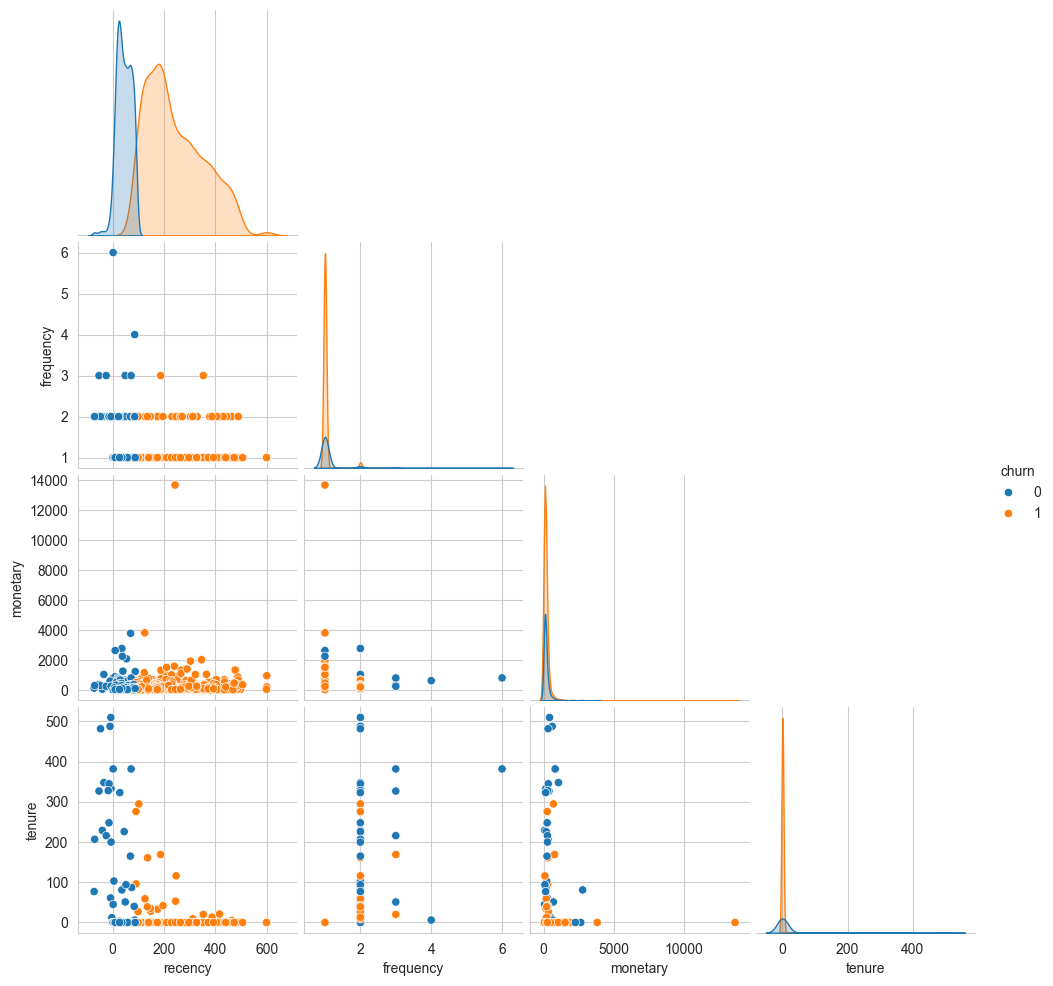

In [20]:
sample = customer_features.sample(2000, random_state=42)

sns.pairplot(
    sample[['recency','frequency','monetary','tenure','churn']],
    hue='churn',
    corner=True
)

### Observation

The pair plot provides a visual comparison of the relationships between Recency, Frequency, Monetary, and Tenure across the two churn classes.

Although some overlap exists between active and churned customers, the visualization indicates that combinations of these behavioral features can help distinguish customer segments. This supports the use of machine learning models that learn patterns from multiple features simultaneously rather than relying on a single variable.